# Conversational Multimodal Pet Adoption Advisor (v3 — Local LLM + ChromaDB)

## Objectif général
Ce notebook construit le **layer de retrieval** du système de recommandation d'adoption :
- Extrait les attributs tabulaires + la colonne `Description` de chaque chien → fiche structurée lisible
- Appelle un **LLM local** (Qwen2.5-3B-Instruct, GPU) pour générer une **description riche** en langage naturel
- Encode cette description avec `all-MiniLM-L6-v2` (384-d) → PCA adaptatif (90 % variance) = `text_emb`
- Encode l'image avec CLIP ViT-B/32 (512-d) → PCA adaptatif (90 % variance) = `img_emb`
- Fusionne : `pet_features = [text_emb_pca ‖ img_emb_pca]` ≈ 128-d (sans colonnes tabulaires brutes)
- Entraîne deux encodeurs (côté pet, côté user) dans un espace partagé via **InfoNCE**
- Stocke les embeddings finaux (128-d, L2-normalisés) dans **ChromaDB** (collection `"pets"`)
- Exporte aussi FAISS + `.npy` pour compatibilité backend

## Architecture

```
[ Données animaux ]
   ├── Attributs tabulaires + Description originale
   │        ↓
   │   Fiche structurée (breed / age / size / couleurs / santé / soins)
   │        ↓
   │   LLM local Qwen2.5-3B-Instruct (GPU batch) → Description riche (~100–130 mots)
   │        ↓
   └──► MiniLM (384-d) + PCA adaptatif ──┐
                                         ├──► hstack ──► PetEncoder ──► 128-d
   └── Image CLIP ViT-B/32 (512-d) + PCA ┘         (L2-normalize)
                                                         │
                                                         ├──► ChromaDB  (cosine)
                                                         └──► FAISS     (inner product)
[ Requête utilisateur ]
   └── Texte libre → MiniLM ──► UserEncoder ──► 128-d
```

**Principe clé** : Aucune colonne tabulaire OHE/scaled dans le vecteur final.  
Seule la combinaison **texte sémantique riche** (LLM) + **image** (CLIP) pilote la similarité.

## Configuration

| Composant | Outil | Détail |
|---|---|---|
| Génération descriptions | `Qwen/Qwen2.5-3B-Instruct` | Local GPU, `max_new_tokens=250`, batch=32 |
| Text embedding | `all-MiniLM-L6-v2` | 384-d |
| Text PCA | sklearn adaptatif | 90 % variance expliquée |
| Image embedding | CLIP ViT-B/32 | 512-d brut |
| Image PCA | sklearn adaptatif | 90 % variance expliquée |
| Fusion multimodale | hstack | ≈ 128-d |
| Pet / User encoders | PyTorch MLP | 128-d sortie |
| Perte | InfoNCE | temperature=0.07 |
| Stockage vectoriel | ChromaDB + FAISS | similarité cosinus |


---
## 0 — Installation des dépendances

In [1]:
!pip install -q faiss-cpu sentence-transformers chromadb openai
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q transformers accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 69.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
ERROR: pip's depen

---
## 1 — Imports et configuration du LLM local

Charge **Qwen2.5-3B-Instruct** en `float16` sur GPU (Kaggle T4, ~6 Go VRAM).
Le pipeline HuggingFace est configuré avec `max_new_tokens=250` et `max_length=None` pour éviter le conflit avec le `generation_config.json` du modèle.

In [2]:
import os
import json
from pathlib import Path
from openai import OpenAI
import chromadb
import clip
import faiss
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import pickle
import time
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Local LLM — runs entirely on Kaggle GPU, zero API calls, no rate limits ──
# Qwen2.5-3B  : ~6 GB fp16 → ~20 min for 7 656 descriptions on T4
# Mistral-7B  : ~14 GB fp16 → slightly better quality, ~35 min on T4
#   swap the constant below to switch models:
LOCAL_MODEL = "Qwen/Qwen2.5-3B-Instruct" #"mistralai/Mistral-7B-Instruct-v0.3"
# LOCAL_MODEL = "mistralai/Mistral-7B-Instruct-v0.3"

print(f"Loading {LOCAL_MODEL} ...")
_tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL, trust_remote_code=True)
_llm = AutoModelForCausalLM.from_pretrained(
    LOCAL_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
_llm.eval()

# Pipeline wrapper — we will call it with a list of prompts for batched GPU inference
_pipe = pipeline(
    "text-generation",
    model=_llm,
    tokenizer=_tokenizer,
    max_new_tokens=250,
    temperature=0.75,
    do_sample=True,
    pad_token_id=_tokenizer.eos_token_id,
    return_full_text=False,
    truncation=True,
    max_length=None,       # ← override Qwen's generation_config.max_length=20
)

# Also patch the model's generation_config directly to silence the warning
if hasattr(_llm, "generation_config"):
    _llm.generation_config.max_length = None
    _llm.generation_config.max_new_tokens = 250

DEMO_MODE = False
print(f"Model ready on {next(_llm.parameters()).device}")


Device: cuda
Loading Qwen/Qwen2.5-3B-Instruct ...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'max_length', 'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Model ready on cuda:0


---
## 2 — Configuration des répertoires et constantes

| Constante | Valeur | Rôle |
|---|---|---|
| `TEXT_DIM` | 384 | Dimension brute MiniLM |
| `PCA_DIM` | 64 | Cible PCA par modalité (remplacé par `TARGET_VARIANCE`) |
| `TARGET_VARIANCE` | 0.90 | PCA adaptatif : sklearn choisit le nb de dims pour 90 % de variance |
| `EMBED_DIM` | 128 | Dimension de sortie des encodeurs Pet/User |


In [3]:
DATA_DIR  = "/kaggle/input/competitions/petfinder-adoption-prediction/train"
IMAGE_DIR = "/kaggle/input/competitions/petfinder-adoption-prediction/train_images"
OUTPUT    = Path("/kaggle/working/artifacts")
OUTPUT.mkdir(exist_ok=True)

# ChromaDB persistent directory
CHROMA_DIR = OUTPUT / "chroma_db"

# Embedding dimensions
#EMBED_DIM = 128   # Shared latent space (pet encoder + user encoder output)
TEXT_DIM  = 384   # MiniLM output dimension
PCA_DIM   = 64    # PCA reduction for each modality before fusion


# AJOUTER
TARGET_VARIANCE = 0.90   # PCA gardera autant de dims que nécessaire pour 90% variance
EMBED_DIM       = 128    # dimension de SORTIE des encodeurs (inchangée)


print(f"Output dir: {OUTPUT}")
print(f"ChromaDB dir: {CHROMA_DIR}")


Output dir: /kaggle/working/artifacts
ChromaDB dir: /kaggle/working/artifacts/chroma_db


---
## 3 — Chargement et décodage des données

Lit `train.csv`, filtre les chiens (`Type == 1`), puis décode :
- `Breed1` / `Breed2` → noms de races via `breed_labels.csv`
- `Color1` / `Color2` / `Color3` → noms de couleurs via `color_labels.csv`

In [4]:
df = pd.read_csv(f"{DATA_DIR}/train.csv")

# Garder uniquement les chiens (Type == 1)
df = df[df["Type"] == 1]

df_original = df.copy()
pet_ids = df["PetID"].values

print(f"Dataset: {len(df):,} animaux — {df.shape[1]} colonnes")
print(f"Colonnes: {df.columns.tolist()}")
df.head(3)

Dataset: 8,132 animaux — 24 colonnes
Colonnes: ['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed']


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [5]:
import os

"""ef show_tree(path="/kaggle/input", dirs_only=True, max_depth=4, _prefix="", _depth=0):
    if _depth > max_depth:
        return
    try:
        entries = sorted(os.scandir(path), key=lambda e: e.name)
    except PermissionError:
        return

    dirs = [e for e in entries if e.is_dir()]
    items = dirs if dirs_only else entries

    for i, entry in enumerate(items):
        connector = "└── " if i == len(items) - 1 else "├── "
        print(f"{_prefix}{connector}{entry.name}/")
        extension = "    " if i == len(items) - 1 else "│   "
        show_tree(entry.path, dirs_only, max_depth, _prefix + extension, _depth + 1)

show_tree("/kaggle/input")"""

'ef show_tree(path="/kaggle/input", dirs_only=True, max_depth=4, _prefix="", _depth=0):\n    if _depth > max_depth:\n        return\n    try:\n        entries = sorted(os.scandir(path), key=lambda e: e.name)\n    except PermissionError:\n        return\n\n    dirs = [e for e in entries if e.is_dir()]\n    items = dirs if dirs_only else entries\n\n    for i, entry in enumerate(items):\n        connector = "└── " if i == len(items) - 1 else "├── "\n        print(f"{_prefix}{connector}{entry.name}/")\n        extension = "    " if i == len(items) - 1 else "│   "\n        show_tree(entry.path, dirs_only, max_depth, _prefix + extension, _depth + 1)\n\nshow_tree("/kaggle/input")'

In [6]:
# ── Mapping Breed1 / Breed2 → labels lisibles ──────────────────────────────
breed_labels_df = pd.read_csv("/kaggle/input/competitions/petfinder-adoption-prediction/breed_labels.csv")
breed_map = dict(zip(breed_labels_df["BreedID"], breed_labels_df["BreedName"]))

# Breed1 : race principale (toujours présente)
df["Breed1"] = df["Breed1"].map(lambda x: breed_map.get(int(x), "Mixed"))

# Breed2 : 0 = chien de race pure (pas de seconde race)
df["Breed2"] = df["Breed2"].map(
    lambda x: "Purebred" if int(x) == 0 else breed_map.get(int(x), "Mixed")
)

print("Breed1 (top 5):\n", df["Breed1"].value_counts().head())
print("\nBreed2 (top 5):\n", df["Breed2"].value_counts().head())

Breed1 (top 5):
 Breed1
Mixed Breed           5923
Labrador Retriever     205
Shih Tzu               189
Poodle                 167
Terrier                161
Name: count, dtype: int64

Breed2 (top 5):
 Breed2
Purebred               5627
Mixed Breed            1727
Terrier                  90
Labrador Retriever       86
German Shepherd Dog      55
Name: count, dtype: int64


In [7]:
# ── Mapping Color1 / Color2 / Color3 → labels lisibles ─────────────────────
color_labels_df = pd.read_csv("/kaggle/input/competitions/petfinder-adoption-prediction/color_labels.csv")
color_map = dict(zip(color_labels_df["ColorID"], color_labels_df["ColorName"]))

# Color1 : couleur principale (toujours présente)
df["Color1"] = df["Color1"].map(lambda x: color_map.get(int(x), "Unknown"))

# Color2 / Color3 : 0 = pas de couleur secondaire/tertiaire
df["Color2"] = df["Color2"].map(
    lambda x: "None" if int(x) == 0 else color_map.get(int(x), "Unknown")
)
df["Color3"] = df["Color3"].map(
    lambda x: "None" if int(x) == 0 else color_map.get(int(x), "Unknown")
)

print("Color1 (top 5):\n", df["Color1"].value_counts().head())
print("\nColor2 (top 5):\n", df["Color2"].value_counts().head())
print("\nColor3 (top 5):\n", df["Color3"].value_counts().head())

Color1 (top 5):
 Color1
Black     3944
Brown     2659
Cream      580
White      363
Golden     342
Name: count, dtype: int64

Color2 (top 5):
 Color2
None      2986
Brown     2336
White     1555
Cream      628
Golden     291
Name: count, dtype: int64

Color3 (top 5):
 Color3
None      6422
White     1230
Cream      262
Golden      89
Yellow      76
Name: count, dtype: int64


In [8]:
df = df.drop(columns=["RescuerID", "Quantity", "Fee", "State"], errors="ignore")

---
## 4 — Construction des fiches JSON par animal

Pour chaque chien, `build_pet_json()` extrait les champs pertinents et convertit tous les codes numériques en labels lisibles (genre, taille, fourrure, santé, soins).  
Le résultat est persisté dans `pet_data_raw.json` pour inspection et debugging.

> **Note** : `Breed1`, `Breed2`, `Color1/2/3` sont déjà décodés en chaînes lisibles à cette étape (cf. section 3).


In [9]:
# Mapping de codes PetFinder vers labels lisibles
TYPE_MAP       = {1: "Dog", 2: "Cat"}
GENDER_MAP     = {1: "Male", 2: "Female", 3: "Mixed"}
SIZE_MAP       = {1: "Small", 2: "Medium", 3: "Large", 4: "Extra Large"}
FUR_MAP        = {1: "Short", 2: "Medium", 3: "Long"}
VACCINATED_MAP = {1: "Yes", 2: "No", 3: "Unknown"}
DEWORMED_MAP   = {1: "Yes", 2: "No", 3: "Unknown"}
STERILIZED_MAP = {1: "Yes", 2: "No", 3: "Unknown"}
HEALTH_MAP     = {1: "Healthy", 2: "Minor Injury", 3: "Serious Injury", 4: "Severe Injury"}


def build_pet_json(row) -> dict:
    """Extract structured attributes for a single pet.
    Breed et Color sont déjà des labels lisibles (mappés avant cet appel).
    """
    breed2 = str(row.get("Breed2", "")).strip()
    color2 = str(row.get("Color2", "")).strip()
    color3 = str(row.get("Color3", "")).strip()

    return {
        "animal_type":       TYPE_MAP.get(row.get("Type"), "Unknown"),
        "breed_primary":     str(row.get("Breed1", "")).strip() or "Mixed",
        "breed_secondary":   breed2 if breed2 not in ("", "Purebred", "None") else None,
        "is_purebred":       breed2 == "Purebred",
        "age_months":        int(row.get("Age", 0)),
        "gender":            GENDER_MAP.get(row.get("Gender"), "Unknown"),
        "size":              SIZE_MAP.get(row.get("MaturitySize"), "Unknown"),
        "fur_length":        FUR_MAP.get(row.get("FurLength"), "Unknown"),
        "vaccinated":        VACCINATED_MAP.get(row.get("Vaccinated"), "Unknown"),
        "dewormed":          DEWORMED_MAP.get(row.get("Dewormed"), "Unknown"),
        "sterilized":        STERILIZED_MAP.get(row.get("Sterilized"), "Unknown"),
        "health":            HEALTH_MAP.get(row.get("Health"), "Unknown"),
        "color_primary":     str(row.get("Color1", "")).strip() or "Unspecified",
        "color_secondary":   color2 if color2 not in ("", "None") else None,
        "color_tertiary":    color3 if color3 not in ("", "None") else None,
        "description":       str(row.get("Description", "")).strip() or "No description provided",
    }


pet_data_raw = {str(pet_ids[i]): build_pet_json(df.iloc[i]) for i in range(len(df))}

# Persist to disk for inspection / debugging
pet_data_path = OUTPUT / "pet_data_raw.json"
pet_data_path.write_text(json.dumps(pet_data_raw, indent=2))

print(f"Saved pet data JSON: {pet_data_path}")
print(f"Example (first pet):\n{json.dumps(list(pet_data_raw.values())[0], indent=2)}")


Saved pet data JSON: /kaggle/working/artifacts/pet_data_raw.json
Example (first pet):
{
  "animal_type": "Dog",
  "breed_primary": "Mixed Breed",
  "breed_secondary": null,
  "is_purebred": true,
  "age_months": 1,
  "gender": "Male",
  "size": "Medium",
  "fur_length": "Medium",
  "vaccinated": "Yes",
  "dewormed": "Yes",
  "sterilized": "No",
  "health": "Healthy",
  "color_primary": "Brown",
  "color_secondary": "White",
  "color_tertiary": null,
  "description": "Their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in Subang Jaya. Gave birth to them at the roadside. They are all healthy and adorable puppies. Already dewormed, vaccinated and ready to go to a home. No tying or caging for long hours as guard dogs. However, it is acceptable to cage or tie for precautionary purposes. Interested to adopt pls call me."
}


---
## 5 — Génération des descriptions riches (LLM local GPU)

Génère une description narrative (~100–130 mots) pour chaque chien en utilisant **Qwen2.5-3B-Instruct** localement sur GPU — aucun appel API, aucun rate limit.

### Stratégie de prompt
Le `SYSTEM_PROMPT` définit une structure en 3 phrases (apparence / personnalité / foyer idéal) et des règles d'écriture strictes.  
Le message utilisateur est une **fiche structurée lisible** (pas un dump JSON brut) incluant :
- Race, âge converti en langage naturel via `_age_label()` (ex : `"2-year-old"`, `"8-month-old puppy"`)
- Taille, longueur de fourrure, couleurs
- Statut vaccin / vermifuge / stérilisation + santé
- Description originale du refuge (jusqu'à 450 caractères) — **signal prioritaire**

### Paramètres de génération
| Paramètre | Valeur | Justification |
|---|---|---|
| `max_new_tokens` | 250 | Permet 3 phrases complètes (~100–130 mots) |
| `temperature` | 0.75 | Équilibre créativité / cohérence |
| `GPU_BATCH_SIZE` | 32 | ~10 Go VRAM disponibles après Qwen sur T4 |
| `SAVE_EVERY` | 200 | Checkpoint intermédiaire (crash safety) |

### Cache
Les descriptions générées sont mises en cache dans `rich_descriptions.json`.  
Le cache est nettoyé au démarrage pour ne conserver que les chiens (`Type == 1`).


In [10]:
SYSTEM_PROMPT = """\You are an expert pet adoption copywriter at an animal shelter.
Write a compelling, specific adoption profile for a dog in exactly 3 sentences — no headers, no bullets.

Sentence 1 — APPEARANCE: breed, size, coat, color, age in vivid natural language.
Sentence 2 — PERSONALITY & CARE: temperament from breed traits + shelter notes + care status.
Sentence 3 — IDEAL HOME: a concrete picture of the best adopter or family.

RULES:
- Name the breed, dominant color, and size. Convert age_months to "X-year-old" or "X-month-old puppy".
- Puppies (<12 mo): emphasize playfulness and training potential.
- Seniors (>84 mo): emphasize calm companionship and loyalty.
- If vaccinated + dewormed + sterilized all Yes: weave "fully up-to-date on care" in naturally.
- If health ≠ Healthy: mention it honestly but compassionately.
- Prioritize the shelter's own description — they know this dog personally.
- NEVER start with "Meet", "This dog is looking for", or "Don't miss your chance".
- NEVER mention IDs, codes, or JSON keys.
- Write in fluent English. Target 100–130 words.
"""


def _age_label(months: int) -> str:
    """Convert age in months to a human-readable string."""
    if months < 3:
        return f"{months}-month-old puppy"
    if months < 12:
        return f"{months}-month-old"
    years = months // 12
    rem   = months % 12
    if rem == 0:
        return f"{years}-year-old"
    return f"{years} year{'s' if years > 1 else ''} and {rem} month{'s' if rem > 1 else ''} old"


def _build_prompt(pet_json: dict) -> str:
    """Format a pet dict into a rich, narrative prompt for the LLM."""
    age_months = pet_json.get("age_months", 0)
    age_label  = _age_label(age_months)

    # Age category hint
    if age_months < 12:
        age_hint = "PUPPY"
    elif age_months > 84:
        age_hint = "SENIOR"
    else:
        age_hint = "ADULT"

    # Breed line
    breed_primary = pet_json.get("breed_primary", "Mixed")
    breed_secondary = pet_json.get("breed_secondary")
    is_purebred = pet_json.get("is_purebred", False)
    if is_purebred:
        breed_line = f"Purebred {breed_primary}"
    elif breed_secondary:
        breed_line = f"{breed_primary} × {breed_secondary} mix"
    else:
        breed_line = f"{breed_primary} (mix)"

    # Colors
    colors = ", ".join(filter(None, [
        pet_json.get("color_primary"),
        pet_json.get("color_secondary"),
        pet_json.get("color_tertiary"),
    ])) or "Unspecified"

    # Care status
    vax  = pet_json.get("vaccinated",  "Unknown")
    dew  = pet_json.get("dewormed",    "Unknown")
    ster = pet_json.get("sterilized",  "Unknown")
    if vax == dew == ster == "Yes":
        care_status = "Fully vaccinated, dewormed, and sterilized"
    else:
        parts = []
        if vax  == "Yes": parts.append("vaccinated")
        if dew  == "Yes": parts.append("dewormed")
        if ster == "Yes": parts.append("sterilized")
        care_status = (", ".join(parts).capitalize() if parts else "Care status unknown") + \
                      (" (some records missing)" if len(parts) < 3 else "")

    health = pet_json.get("health", "Unknown")

    # Original shelter description — most valuable signal, use as much as possible
    shelter_desc = pet_json.get("description", "").strip()
    if shelter_desc and shelter_desc != "No description provided":
        shelter_block = f'Shelter\'s own words: "{shelter_desc[:450]}"'
    else:
        shelter_block = "No shelter description available — infer personality from breed traits."

    user_msg = f"""\
Write an adoption profile for this dog.

--- DOG PROFILE ---
Breed      : {breed_line}
Age        : {age_label}  [{age_hint}]
Gender     : {pet_json.get("gender", "Unknown")}
Size       : {pet_json.get("size", "Unknown")}
Coat       : {pet_json.get("fur_length", "Unknown")}-length
Colors     : {colors}
Health     : {health}
Care       : {care_status}
{shelter_block}
---

Write the 3-sentence adoption profile now (100–130 words, no headers, no bullets).\
"""

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ]
    return _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def generate_rich_description(pet_json: dict, pet_id: str, demo_mode: bool = False) -> str:
    """Single-item generation — used as fallback only."""
    if demo_mode:
        breed = pet_json.get("breed_primary", "dog")
        color = pet_json.get("color_primary", "")
        age   = _age_label(pet_json.get("age_months", 0))
        desc  = pet_json.get("description", "")
        return (
            f"A {color} {breed}, {age}. "
            f"{desc[:300] if desc and desc != 'No description provided' else 'Friendly and available for adoption.'}"
        )
    try:
        prompt = _build_prompt(pet_json)
        result = _pipe(prompt)[0]["generated_text"].strip()
        # Strip any accidental prompt echo
        if result.startswith(("---", "Breed", "Write")):
            result = result.split("\n\n", 1)[-1].strip()
        return result
    except Exception as e:
        print(f"[WARNING] Local model error for {pet_id}: {e}")
        desc = pet_json.get("description", "")
        return f"{pet_json.get('breed_primary', 'Dog')}. {desc[:200] if desc else 'Available for adoption.'}"


# Load existing cache to avoid redundant API calls
# ── Cache ───────────────────────────────────────────────────────────────────
rich_descriptions_path = OUTPUT / "rich_descriptions.json"
if rich_descriptions_path.exists():
    rich_descriptions = json.loads(rich_descriptions_path.read_text())
    print(f"Loaded {len(rich_descriptions)} cached descriptions.")
else:
    rich_descriptions = {}


# ✅ COLLER ICI — nettoie le cache des animaux hors Type==1
# Nettoie le cache des animaux hors Type==1
dog_ids_set = set(str(pid) for pid in pet_ids)
rich_descriptions = {k: v for k, v in rich_descriptions.items() if k in dog_ids_set}
rich_descriptions_path.write_text(json.dumps(rich_descriptions, indent=2))
print(f"Cache nettoyé : {len(rich_descriptions):,} descriptions (chiens uniquement)")



# ── Génération ──────────────────────────────────────────────────────────────
missing_pets = [pid for pid in pet_data_raw.keys() if pid not in rich_descriptions]
print(f"Generating descriptions for {len(missing_pets)} pets...")

# ── Batched GPU inference — no rate limits, no API calls ──────────────────
GPU_BATCH_SIZE  = 32    # prompts sent to GPU at once (tune down if OOM on T4)
SAVE_EVERY      = 200   # save cache every N descriptions (crash safety)

missing_pets = [pid for pid in pet_data_raw.keys() if pid not in rich_descriptions]
print(f"Generating {len(missing_pets):,} descriptions on {DEVICE} ...")

if DEMO_MODE:
    # Fallback: no GPU — generate synthetic descriptions
    for pet_id in tqdm(missing_pets, desc="Demo mode"):
        rich_descriptions[pet_id] = generate_rich_description(
            pet_data_raw[pet_id], pet_id, demo_mode=True
        )
    rich_descriptions_path.write_text(json.dumps(rich_descriptions, indent=2))
else:
    # Build all prompts upfront (fast)
    all_prompts = [_build_prompt(pet_data_raw[pid]) for pid in missing_pets]

    generated = []
    for start in tqdm(range(0, len(all_prompts), GPU_BATCH_SIZE), desc="GPU batches"):
        batch_prompts = all_prompts[start : start + GPU_BATCH_SIZE]
        try:
            outputs = _pipe(batch_prompts, batch_size=GPU_BATCH_SIZE)
            for out in outputs:
                text = out[0]["generated_text"].strip()
                # Strip any accidental prompt echo
                if text.startswith(("---", "Breed", "Write")):
                    text = text.split("\n\n", 1)[-1].strip()
                generated.append(text)
        except Exception as e:
            print(f"[WARNING] Batch {start//GPU_BATCH_SIZE} failed: {e} — using fallback")
            for i, pid in enumerate(missing_pets[start : start + GPU_BATCH_SIZE]):
                generated.append(generate_rich_description(pet_data_raw[pid], pid))

        # Periodic save
        if (start // GPU_BATCH_SIZE + 1) % (SAVE_EVERY // GPU_BATCH_SIZE) == 0:
            partial = dict(zip(missing_pets[:len(generated)], generated))
            rich_descriptions.update(partial)
            rich_descriptions_path.write_text(json.dumps(rich_descriptions, indent=2))
            print(f"  Checkpoint saved ({len(rich_descriptions):,} total)")

    # Final merge + save
    rich_descriptions.update(dict(zip(missing_pets, generated)))
    rich_descriptions_path.write_text(json.dumps(rich_descriptions, indent=2))

print(f"\nSaved {len(rich_descriptions)} descriptions to {rich_descriptions_path}")

print("\nExamples:")
for i, (pet_id, desc) in enumerate(list(rich_descriptions.items())[:3]):
    print(f"  {pet_id}: {desc[:120]}...")


<>:1: SyntaxWarning: invalid escape sequence '\Y'
<>:1: SyntaxWarning: invalid escape sequence '\Y'
/tmp/ipykernel_57/606833301.py:1: SyntaxWarning: invalid escape sequence '\Y'
  SYSTEM_PROMPT = """\You are an expert pet adoption copywriter at an animal shelter.


Cache nettoyé : 0 descriptions (chiens uniquement)
Generating descriptions for 8132 pets...
Generating 8,132 descriptions on cuda ...



GPU batches:   2%|▏         | 6/255 [02:39<1:51:29, 26.87s/it]

  Checkpoint saved (192 total)



GPU batches:   4%|▍         | 10/255 [04:24<1:48:35, 26.59s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

GPU batches:   5%|▍         | 12/255 [05:20<1:51:01, 27.41s/it]

...

  Checkpoint saved (7,872 total)



GPU batches:  99%|█████████▉| 252/255 [1:59:21<01:30, 30.10s/it]

  Checkpoint saved (8,064 total)



GPU batches: 100%|██████████| 255/255 [2:00:25<00:00, 28.33s/it]


Saved 8132 descriptions to /kaggle/working/artifacts/rich_descriptions.json

Examples:
  3422e4906: Sentence 1: This handsome medium-sized, medium-haired 1-month-old puppy, with a mix of brown and white fur, is full of e...
  5842f1ff5: Sentence 1: A playful 4-month-old mixed breed with a sleek short coat of black and brown, this energetic pup is a bundle...
  850a43f90: ADOPTER IDEAL: A home where Hunter can unleash his boundless energy, playing with abandon under the watchful eye of a pa...


In [11]:
# ── Aperçu des descriptions générées ───────────────────────────────────────
import textwrap

N_DISPLAY = 100

print(f"{'='*70}")
print(f"  APERÇU — {N_DISPLAY} descriptions générées (chiens uniquement)")
print(f"{'='*70}\n")

# ✅ FIX : utiliser pet_ids (déjà filtré Type==1) au lieu de rich_descriptions.keys()
sample_ids = [str(pid) for pid in pet_ids[:N_DISPLAY]]

# Statistiques cache
dog_ids_in_cache = [pid for pid in sample_ids if pid in rich_descriptions]
total_dog_cached = sum(1 for pid in [str(p) for p in pet_ids] if pid in rich_descriptions)
print(f"Cache total     : {len(rich_descriptions):,} descriptions (chats + chiens)")
print(f"Chiens en cache : {total_dog_cached:,} / {len(pet_ids):,}\n")

for i, pid in enumerate(sample_ids, 1):
    if pid not in rich_descriptions:
        print(f"[{i:02d}] PetID: {pid} — pas encore généré\n")
        continue

    # ✅ FIX : df_original est filtré dogs only → lookup sûr
    mask = df_original["PetID"] == pid
    if not mask.any():
        continue

    row    = df_original[mask].iloc[0]
    desc   = rich_descriptions[pid]
    breed1 = df.loc[df["PetID"] == pid, "Breed1"].values[0]
    color1 = df.loc[df["PetID"] == pid, "Color1"].values[0]
    age    = int(row["Age"])
    gender = {1: "Male", 2: "Female", 3: "Mixed"}.get(int(row["Gender"]), "?")

    print(f"[{i:02d}] PetID : {pid}")
    print(f"     {breed1} | {color1} | {age} mths | {gender}")
    print(f"     ↳ {textwrap.fill(desc, width=65, subsequent_indent='       ')}")
    print()

  APERÇU — 100 descriptions générées (chiens uniquement)

Cache total     : 8,132 descriptions (chats + chiens)
Chiens en cache : 8,132 / 8,132

[01] PetID : 3422e4906
     Mixed Breed | Brown | 1 mths | Male
     ↳ Sentence 1: This handsome medium-sized, medium-haired 1-month-old
       puppy, with a mix of brown and white fur, is full of
       energy and boundless curiosity, perfect for playful
       households. Sentence 2: Sheltered from the harsh realities
       of life at the roadside, this sweet pup has already been
       vaccinated and dewormed, making him ready for a loving
       home where he can learn to trust humans again and enjoy
       gentle training sessions. Sentence 3: Ideal homes would be
       those with patience to guide him through his early
       socialization stages and provide a safe, secure space for
       him to grow into a well-behaved, loyal companion.

[02] PetID : 5842f1ff5
     Mixed Breed | Black | 4 mths | Female
     ↳ Sentence 1: A playful 4-

---
## 6 — Embeddings texte (MiniLM sur les descriptions riches)

Encode les descriptions générées par le LLM avec `all-MiniLM-L6-v2` (384-d), puis applique un PCA adaptatif (`TARGET_VARIANCE=0.90`) — sklearn détermine automatiquement le nombre de dimensions nécessaires pour expliquer 90 % de la variance.

In [12]:
# Load MiniLM sentence encoder
text_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode rich descriptions (not raw tabular descriptions)
rich_desc_list = [rich_descriptions.get(str(pid), "") for pid in pet_ids]
text_emb_raw = text_model.encode(rich_desc_list, batch_size=64, show_progress_bar=True)
text_emb_raw = text_emb_raw.astype("float32")
print(f"Raw text embeddings: {text_emb_raw.shape}  (expected: {len(df)} x 384)")

# Reduce to PCA_DIM with PCA
# PAR
pca_text = PCA(n_components=TARGET_VARIANCE)   # sklearn choisit n automatiquement
text_emb_pca = pca_text.fit_transform(text_emb_raw).astype("float32")
TEXT_PCA_DIM = text_emb_pca.shape[1]
print(f"Text  PCA : {text_emb_raw.shape[1]}-d → {TEXT_PCA_DIM}-d  "
      f"(variance expliquée : {pca_text.explained_variance_ratio_.sum():.1%})")

# Persist PCA model for inference in retrieval.py
with open(OUTPUT / "pca_text.pkl", "wb") as f:
    pickle.dump(pca_text, f)

print(f"Text embeddings after PCA: {text_emb_pca.shape}  ({TEXT_PCA_DIM}-d adaptive)")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Raw text embeddings: (8132, 384)  (expected: 8132 x 384)
Text  PCA : 384-d → 133-d  (variance expliquée : 90.1%)
Text embeddings after PCA: (8132, 133)  (133-d adaptive)


---
## 7 — Embeddings image (CLIP ViT-B/32)

Encode l'image principale de chaque chien avec CLIP ViT-B/32 (512-d), puis réduit via PCA adaptatif (90 % variance). Les images manquantes sont remplacées par un vecteur zéro.

In [23]:
# Load CLIP model
model_img, preprocess = clip.load("ViT-B/32", device=DEVICE)
model_img.eval()
print(f"IMAGE_DIR exists: {os.path.exists(IMAGE_DIR)}")


def encode_image(pet_id: str) -> np.ndarray:
    """Encode a single pet image to 512-d CLIP embedding.
    Returns a zero vector if the image file is missing or unreadable.
    The primary image is named '{pet_id}-1.jpg'.
    """
    img_path = os.path.join(IMAGE_DIR, f"{pet_id}-1.jpg")
    if not os.path.exists(img_path):
        return np.zeros(512, dtype="float32")
    try:
        image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            return model_img.encode_image(image).cpu().numpy().flatten().astype("float32")
    except Exception as e:
        print(f"[WARNING] Failed to encode image for {pet_id}: {e}")
        return np.zeros(512, dtype="float32")


# Encode all pet images (512-d)
print("Encoding images with CLIP...")
img_emb_raw = np.stack([encode_image(str(pid)) for pid in tqdm(pet_ids, desc="CLIP encoding")])
img_emb_raw = img_emb_raw.astype("float32")

zero_mask = (img_emb_raw == 0).all(axis=1)
print(f"Missing images: {zero_mask.sum()} / {len(img_emb_raw)} ({100 * zero_mask.mean():.1f}%)")

# Keep raw 512-d embeddings for dog_finder pipeline
np.save(OUTPUT / "img_emb_raw.npy", img_emb_raw)

# Reduce to PCA_DIM for multimodal fusion
pca_img = PCA(n_components=TARGET_VARIANCE)
img_emb_pca = pca_img.fit_transform(img_emb_raw).astype("float32")
IMG_PCA_DIM = img_emb_pca.shape[1]
print(f"Image PCA : {img_emb_raw.shape[1]}-d → {IMG_PCA_DIM}-d  "
      f"(variance expliquée : {pca_img.explained_variance_ratio_.sum():.1%})")

# Persist PCA model for inference
with open(OUTPUT / "pca_img.pkl", "wb") as f:
    pickle.dump(pca_img, f)

print(f"Image embeddings after PCA: {img_emb_pca.shape}  ({IMG_PCA_DIM}-d adaptive)")


IMAGE_DIR exists: True
Encoding images with CLIP...



CLIP encoding: 100%|██████████| 8132/8132 [02:00<00:00, 67.59it/s]


Missing images: 194 / 8132 (2.4%)
Image PCA : 512-d → 146-d  (variance expliquée : 90.0%)
Image embeddings after PCA: (8132, 146)  (146-d adaptive)


---
## 8 — Fusion multimodale (texte + image)

Concatène `text_emb_pca` et `img_emb_pca` en un vecteur `pet_features` (~128-d).

> **Rappel** : Aucune colonne tabulaire (OHE, scaled) n'est incluse dans ce vecteur.  
> Toute l'information factuelle (race, taille, santé…) est portée par la **description textuelle riche** générée en section 5.


In [24]:
# Normalize each modality independently before concatenation
# StandardScaler ensures both modalities contribute equally (no scale dominance)
text_norm = StandardScaler().fit_transform(text_emb_pca).astype("float32")
img_norm  = StandardScaler().fit_transform(img_emb_pca).astype("float32")

# Final pet features: 64-d text + 64-d image = 128-d (NO tabular columns)
pet_features = np.hstack([text_norm, img_norm]).astype("float32")

FUSED_DIM = text_emb_pca.shape[1] + img_emb_pca.shape[1]
print(f"Pet features (final): {pet_features.shape}  "
      f"({TEXT_PCA_DIM}-d text + {IMG_PCA_DIM}-d image = {FUSED_DIM}-d fusionné)")
assert pet_features.shape[1] == FUSED_DIM


Pet features (final): (8132, 279)  (133-d text + 146-d image = 279-d fusionné)


---
## 9 — Encodeurs profonds Pet / User

Deux MLP PyTorch symétriques projettent les vecteurs `pet_features` et les embeddings de requête utilisateur vers un espace latent commun de 128 dimensions, L2-normalisé.

In [25]:
class Encoder(nn.Module):
    """Two-layer MLP that maps variable-dim inputs to a shared EMBED_DIM latent space.

    Output is L2-normalized so cosine similarity == dot product.
    Used for both the pet encoder (128-d in → 128-d out) and
    the user encoder (384-d MiniLM in → 128-d out).
    """

    def __init__(self, in_dim: int, out_dim: int = EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.net(x), dim=-1)


# Pet encoder: 128-d fused features → 128-d latent
pet_encoder = Encoder(FUSED_DIM, EMBED_DIM)  # input=dynamique, output=128 fixe
# User encoder: 384-d MiniLM query embedding → 128-d latent
user_encoder = Encoder(TEXT_DIM, EMBED_DIM)

total_params = sum(
    p.numel() for p in list(pet_encoder.parameters()) + list(user_encoder.parameters())
)
print(f"Total trainable parameters: {total_params:,}")


Total trainable parameters: 237,056


---
## 10 — Entraînement InfoNCE

Minimise la perte InfoNCE (temperature=0.07, inspiré de CLIP) pour rapprocher chaque paire `(user_query, pet)` correspondante et repousser les non-correspondances dans le batch.

In [26]:
def infonce_loss(user_emb: torch.Tensor, pet_emb: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    """InfoNCE contrastive loss.

    For each item i in the batch, user_emb[i] and pet_emb[i] form a positive pair.
    All other (user_emb[i], pet_emb[j!=i]) are treated as negatives.
    Minimizing this loss pulls matching pairs together and pushes non-matches apart.
    Temperature=0.07 follows CLIP's original paper.
    """
    logits = user_emb @ pet_emb.T / temperature
    labels = torch.arange(len(user_emb), device=user_emb.device)
    return F.cross_entropy(logits, labels)


BATCH_SIZE      = 32
N_EPOCHS        = 3
STEPS_PER_EPOCH = 200

optimizer = torch.optim.Adam(
    list(pet_encoder.parameters()) + list(user_encoder.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

pet_encoder.train()
user_encoder.train()

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for step in range(STEPS_PER_EPOCH):
        idx = np.random.choice(len(df), BATCH_SIZE, replace=False)

        # User query = "I'm looking for: {rich_description of the target pet}"
        # This teaches the user encoder to match natural-language queries to pet embeddings
        texts = [
            f"I'm looking for: {rich_descriptions.get(str(pet_ids[i]), '')}"
            for i in idx
        ]
        user_np = text_model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=False)
        pet_np  = pet_features[idx]

        user_batch = torch.from_numpy(user_np).float()
        pet_batch  = torch.from_numpy(pet_np).float()

        loss = infonce_loss(user_encoder(user_batch), pet_encoder(pet_batch))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / STEPS_PER_EPOCH
    print(f"Epoch {epoch + 1}/{N_EPOCHS}  avg_loss={avg_loss:.4f}")


Epoch 1/3  avg_loss=0.6247
Epoch 2/3  avg_loss=0.0394
Epoch 3/3  avg_loss=0.0200


---
## 11 — Stockage ChromaDB

Encode tous les chiens via le `PetEncoder` entraîné, normalise L2, puis indexe dans ChromaDB (metric=cosine).  
Les métadonnées stockées par animal : `name`, `breed`, `age_months`, `gender`, `size`, `fee`, `description` (riche).


In [27]:
# Initialize ChromaDB persistent client
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Delete existing collection if re-running notebook
try:
    chroma_client.delete_collection("pets")
    print("Deleted existing 'pets' collection.")
except Exception:
    pass

# Create new collection with cosine metric (hnsw:space=cosine)
collection = chroma_client.create_collection(
    "pets",
    metadata={"hnsw:space": "cosine"}
)
print("Created ChromaDB collection 'pets'.")

# Encode all pets through the trained pet encoder and L2-normalize
pet_encoder.eval()
with torch.no_grad():
    pet_emb = pet_encoder(torch.from_numpy(pet_features)).numpy().astype("float32")
faiss.normalize_L2(pet_emb)  # In-place L2 normalization

# Insert into ChromaDB in batches (ChromaDB default batch limit: ~5000)
BATCH = 1000
for start in tqdm(range(0, len(pet_ids), BATCH), desc="Adding to ChromaDB"):
    end       = min(start + BATCH, len(pet_ids))
    batch_ids = [str(pid) for pid in pet_ids[start:end]]
    batch_emb = pet_emb[start:end].tolist()
    batch_meta = []

    for i in range(start, end):
        row = df_original.iloc[i]
        batch_meta.append({
            "name":        str(row.get("Name", "Unknown"))[:100],
            "breed":       str(row.get("Breed1", ""))[:100],
            "animal_type": int(row.get("Type", 0)),
            "size":        int(row.get("MaturitySize", 0)),
            "age_months":  int(row.get("Age", 0)),
            "fee":         float(row.get("Fee", 0)),
            "gender":      int(row.get("Gender", 0)),
            "description": str(rich_descriptions.get(str(pet_ids[i]), ""))[:500],
        })

    collection.add(
        ids=batch_ids,
        embeddings=batch_emb,
        metadatas=batch_meta,
    )

print(f"\nChromaDB: {collection.count():,} pets indexed successfully.")


Deleted existing 'pets' collection.
Created ChromaDB collection 'pets'.



Adding to ChromaDB: 100%|██████████| 9/9 [00:05<00:00,  1.67it/s]


ChromaDB: 8,132 pets indexed successfully.


---
## 12 — Index FAISS (compatibilité backend)

Construit un index `IndexFlatIP` (inner product sur vecteurs L2-normalisés ≡ cosine similarity) pour la compatibilité avec le backend de retrieval Python.

In [28]:
# FAISS inner-product index (works as cosine similarity after L2 normalization)
index = faiss.IndexFlatIP(EMBED_DIM)
index.add(pet_emb)
print(f"FAISS Index: {index.ntotal:,} vectors of dimension {EMBED_DIM}")

# Save embeddings and pet ID array for the backend retrieval module
np.save(OUTPUT / "pet_emb.npy", pet_emb)
np.save(OUTPUT / "pet_ids.npy", np.array(pet_ids))
print(f"Saved pet_emb.npy ({pet_emb.shape}) and pet_ids.npy ({len(pet_ids)})")


FAISS Index: 8,132 vectors of dimension 128
Saved pet_emb.npy ((8132, 128)) and pet_ids.npy (8132)


---
## 13 — Calibration des seuils de retrieval

Calcule les percentiles de score cosinus sur l'ensemble des chiens pour définir des seuils `THRESHOLDS` (haut / moyen / bas) utilisés par `retrieval.py` pour filtrer et classer les résultats.

Entropy distribution — mean=1.592  std=0.005
Calibrated thresholds — low (P25)=1.588  high (P75)=1.596


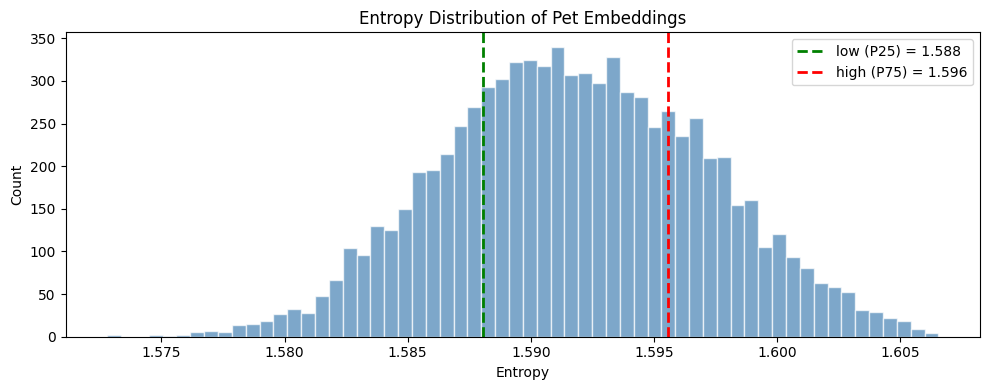

In [29]:
def score_entropy(scores: np.ndarray) -> float:
    """Shannon entropy of softmax-normalized similarity scores.

    High entropy = scores spread out (uncertain match).
    Low entropy  = one pet clearly dominates (confident match).
    Used to determine when to ask the user for more preferences vs show results.
    """
    probs = np.exp(scores) / np.sum(np.exp(scores))
    return float(-np.sum(probs * np.log(probs + 1e-9)))


def calibrate_thresholds(
    index: faiss.Index,
    pet_emb: np.ndarray,
    k: int = 5,
    low_pct: float = 25.0,
    high_pct: float = 75.0,
) -> dict:
    """Map the entropy distribution and return data-driven low/high thresholds.

    Returns a dict with: low, high, mean, std.
    These are used by retrieval.py to decide whether to return pets
    immediately or ask the user for more information first.
    """
    D, _ = index.search(pet_emb, k)
    entropies = np.array([score_entropy(d) for d in D])

    thresholds = {
        "low":  float(np.percentile(entropies, low_pct)),
        "high": float(np.percentile(entropies, high_pct)),
        "mean": float(entropies.mean()),
        "std":  float(entropies.std()),
    }
    print(
        f"Entropy distribution — mean={thresholds['mean']:.3f}  std={thresholds['std']:.3f}"
    )
    print(
        f"Calibrated thresholds — "
        f"low (P{low_pct:.0f})={thresholds['low']:.3f}  "
        f"high (P{high_pct:.0f})={thresholds['high']:.3f}"
    )
    return thresholds


THRESHOLDS = calibrate_thresholds(index, pet_emb)

# Optional visualization
try:
    import matplotlib.pyplot as plt

    D_all, _ = index.search(pet_emb, 5)
    all_entropies = [score_entropy(d) for d in D_all]

    plt.figure(figsize=(10, 4))
    plt.hist(all_entropies, bins=60, color="steelblue", edgecolor="white", alpha=0.7)
    plt.axvline(THRESHOLDS["low"],  color="green", linestyle="--", linewidth=2,
                label=f"low (P25) = {THRESHOLDS['low']:.3f}")
    plt.axvline(THRESHOLDS["high"], color="red",   linestyle="--", linewidth=2,
                label=f"high (P75) = {THRESHOLDS['high']:.3f}")
    plt.xlabel("Entropy")
    plt.ylabel("Count")
    plt.title("Entropy Distribution of Pet Embeddings")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("[NOTE] matplotlib not available, skipping visualization.")


In [30]:
user_encoder.eval()


def retrieve_faiss(user_text: str, k: int = 5):
    """Retrieve top-k pets from FAISS given a natural-language user query."""
    emb = text_model.encode([user_text])[0]
    with torch.no_grad():
        u = user_encoder(torch.from_numpy(emb).float().unsqueeze(0)).numpy().astype("float32")
    faiss.normalize_L2(u)
    D, I = index.search(u, k)
    out = df_original.iloc[I[0]][["PetID", "Name", "Breed1", "Age", "Type"]].copy()
    out["score"] = D[0]
    return out


def retrieve_chroma(user_text: str, k: int = 5):
    """Retrieve top-k pets from ChromaDB given a natural-language user query."""
    emb = text_model.encode([user_text])[0]
    with torch.no_grad():
        u = user_encoder(torch.from_numpy(emb).float().unsqueeze(0)).numpy().astype("float32")
    faiss.normalize_L2(u)

    results = collection.query(
        query_embeddings=[u[0].tolist()],   # u[0] = vecteur 1D (128,)
        n_results=k,
    )
    return results


test_prompts = [
    "calm small dog for an apartment, good with kids",
    "active outdoor dog, loves hiking, energetic",
    "quiet senior cat, indoor only, low maintenance",
]

print("=" * 80)
print("FAISS RETRIEVAL TESTS")
print("=" * 80)
for prompt in test_prompts:
    print(f"\nQuery: {prompt}")
    results = retrieve_faiss(prompt, k=3)
    print(results.to_string(index=False))

print("\n" + "=" * 80)
print("CHROMADB RETRIEVAL TESTS")
print("=" * 80)
for prompt in test_prompts:
    print(f"\nQuery: {prompt}")
    results = retrieve_chroma(prompt, k=3)
    print(f"Found {len(results['ids'][0])} results:")
    for pid, dist in zip(results["ids"][0], results["distances"][0]):
        print(f"  PetID={pid}  distance={dist:.3f}")


FAISS RETRIEVAL TESTS

Query: calm small dog for an apartment, good with kids
    PetID   Name  Breed1  Age  Type    score
86547ad6d  Gabby     307    5     1 0.508181
676b51817 Goldie     307  120     1 0.503015
82dd5838f    NaN     307    2     1 0.457714

Query: active outdoor dog, loves hiking, energetic
    PetID    Name  Breed1  Age  Type    score
f3a5451b9   Bingo     128   24     1 0.530844
92d830572 Cricket     307    2     1 0.508866
e470b6bd3    Gigi     109   24     1 0.499735

Query: quiet senior cat, indoor only, low maintenance
    PetID        Name  Breed1  Age  Type    score
05d2022eb      Cooper      69   60     1 0.501899
e678bcc42         NaN      69   48     1 0.493482
844dfd2b4 Friday Girl     307   12     1 0.479394

CHROMADB RETRIEVAL TESTS

Query: calm small dog for an apartment, good with kids
Found 3 results:
  PetID=86547ad6d  distance=0.492
  PetID=676b51817  distance=0.497
  PetID=82dd5838f  distance=0.542

Query: active outdoor dog, loves hiking, energeti

---
## 14 — Sanity-check retrieval

Teste plusieurs requêtes utilisateur types sur les deux backends (FAISS + ChromaDB) pour vérifier la cohérence sémantique des résultats.


---
## 15 — Export des artefacts finaux

In [31]:
# Save encoder weights
torch.save(pet_encoder.state_dict(),  OUTPUT / "pet_encoder.pt")
torch.save(user_encoder.state_dict(), OUTPUT / "user_encoder.pt")
print("Saved encoder weights.")

# Save full DataFrame for metadata lookups in the backend
df_original.to_parquet(OUTPUT / "df_original.parquet", index=False)
print("Saved df_original.parquet.")

# Save calibrated thresholds for retrieval.py
(OUTPUT / "thresholds.json").write_text(json.dumps(THRESHOLDS, indent=2))

# Save pet features dimension for the backend to verify compatibility
(OUTPUT / "pet_features_shape.txt").write_text(str(EMBED_DIM))

print("\nAll artifacts saved to:", OUTPUT)
for f in sorted(OUTPUT.iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / 1024**2
        print(f"  {f.name:40s} {size_mb:8.2f} MB")
    elif f.is_dir() and f.name.startswith("chroma"):
        total_size = sum(p.stat().st_size for p in f.rglob("*") if p.is_file()) / 1024**2
        print(f"  {f.name}/ {total_size:34.2f} MB (directory)")


Saved encoder weights.
Saved df_original.parquet.

All artifacts saved to: /kaggle/working/artifacts
  chroma_db/                              25.00 MB (directory)
  df_original.parquet                          1.88 MB
  img_emb_raw.npy                             15.88 MB
  pca_img.pkl                                  0.29 MB
  pca_text.pkl                                 0.20 MB
  pet_data_raw.json                            6.08 MB
  pet_emb.npy                                  3.97 MB
  pet_encoder.pt                               0.41 MB
  pet_features_shape.txt                       0.00 MB
  pet_ids.npy                                  0.09 MB
  rich_descriptions.json                       3.94 MB
  thresholds.json                              0.00 MB
  user_encoder.pt                              0.51 MB


---
## 16 — Vérification finale

Contrôle la présence et la non-vacuité de tous les artefacts requis pour le déploiement backend.


In [32]:
REQUIRED_FILES = [
    "pet_emb.npy",
    "pet_ids.npy",
    "pet_encoder.pt",
    "user_encoder.pt",
    "df_original.parquet",
    "thresholds.json",
    "pet_features_shape.txt",
    "img_emb_raw.npy",
    "rich_descriptions.json",
    "pca_text.pkl",
    "pca_img.pkl",
    "pet_data_raw.json",
]

print("Artifact verification:")
print("=" * 60)
all_ok = True
for name in REQUIRED_FILES:
    path = OUTPUT / name
    if not path.exists():
        print(f"MISSING: {name}")
        all_ok = False
    elif path.stat().st_size == 0:
        print(f"EMPTY:   {name}")
        all_ok = False
    else:
        size_mb = path.stat().st_size / 1024**2
        print(f"OK:      {name:35s} {size_mb:8.2f} MB")

# Check ChromaDB directory
if CHROMA_DIR.exists() and any(CHROMA_DIR.iterdir()):
    chroma_size = sum(p.stat().st_size for p in CHROMA_DIR.rglob("*") if p.is_file()) / 1024**2
    print(f"OK:      chroma_db/ {chroma_size:32.2f} MB (directory)")
else:
    print("MISSING: chroma_db/")
    all_ok = False

print("=" * 60)
if all_ok:
    print("All artifacts OK. Ready for deployment.")
else:
    print("Some artifacts are missing/empty. Check the notebook run.")


Artifact verification:
OK:      pet_emb.npy                             3.97 MB
OK:      pet_ids.npy                             0.09 MB
OK:      pet_encoder.pt                          0.41 MB
OK:      user_encoder.pt                         0.51 MB
OK:      df_original.parquet                     1.88 MB
OK:      thresholds.json                         0.00 MB
OK:      pet_features_shape.txt                  0.00 MB
OK:      img_emb_raw.npy                        15.88 MB
OK:      rich_descriptions.json                  3.94 MB
OK:      pca_text.pkl                            0.20 MB
OK:      pca_img.pkl                             0.29 MB
OK:      pet_data_raw.json                       6.08 MB
OK:      chroma_db/                            25.00 MB (directory)
All artifacts OK. Ready for deployment.


In [33]:
import shutil

# Zipper tout le dossier chroma_db
shutil.make_archive(
    base_name=str(OUTPUT / "chroma_db_export"),   # nom du zip final
    format="zip",
    root_dir=str(OUTPUT),                          # dossier parent
    base_dir="chroma_db"                           # ce qu'on zippe
)

print(f"✅ ZIP créé : {OUTPUT / 'chroma_db_export.zip'}")
print(f"   Taille : {(OUTPUT / 'chroma_db_export.zip').stat().st_size / 1024**2:.1f} MB")

✅ ZIP créé : /kaggle/working/artifacts/chroma_db_export.zip
   Taille : 13.3 MB
